<a href="https://colab.research.google.com/github/yini2105/stroke_prediction_ml_figma/blob/main/Machine_Learning_classification_model_Yini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install kagglehub
import kagglehub
data = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

100%|██████████| 67.4k/67.4k [00:00<00:00, 397kB/s]

Extracting files...


In [ ]:
import pandas as pd
df = pd.read_csv(data + "/healthcare-dataset-stroke-data.csv")
df.head()

if_stroke = df["stroke"].value_counts()
print(if_stroke)
df.isnull().sum()
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

categorical_to_encoded = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]
df_encoding = pd.get_dummies(df, columns=categorical_to_encoded, drop_first=True) # From caterogical into things the model an understnad an ensure nothing is duplicating
df_encoding.head()

stroke
0    4861
1     249
Name: count, dtype: int64


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,228.69,36.600000,1,True,False,True,False,True,False,False,True,True,False,False
1,51676,61.0,0,0,202.21,28.893237,1,False,False,True,False,False,True,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.500000,1,True,False,True,False,True,False,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.400000,1,False,False,True,False,True,False,False,True,False,False,True
4,1665,79.0,1,0,174.12,24.000000,1,False,False,True,False,False,True,False,False,False,True,False


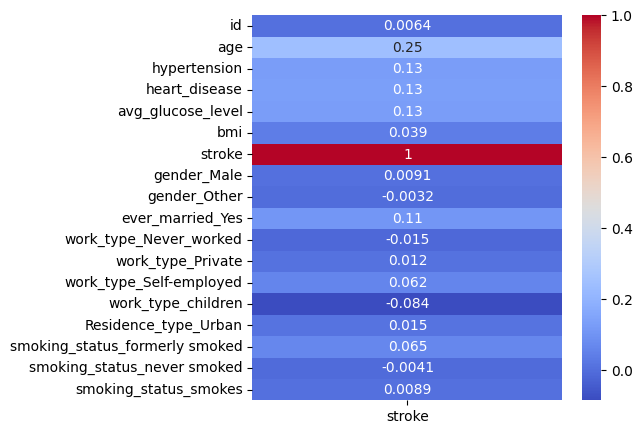

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoding.corr(numeric_only = True)

stroke_corr = corr["stroke"]

plt.figure(figsize=(5,5))
sns.heatmap(stroke_corr.to_frame(), cmap= "coolwarm", annot=True)
plt.show()

In [ ]:
X = df_encoding.drop("stroke", axis = 1)
y = df_encoding["stroke"]
X.shape, y.shape # We will just see the shapes of X which is inputs/varibales so everything except the anwer of strokes and y which is the output answer strokes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y) # First we need to split the model, ensure y is distributed
X_train.shape, X_test.shape # We can can see the changed shape of the varibles input of training and testing

((4088, 17), (1022, 17))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaling = StandardScaler()
X_train = scaling.fit_transform(X_train) # I made sure to fit the transformed training on varibale
X_test = scaling.transform(X_test) # Didn't fit but only transformed since it must be unseen

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, class_weight = "balanced") # The maximum it will try again is 2000 times # Fix the balance
model.fit(X_train, y_train) # Finally, we can fit it over the model

LogisticRegression(class_weight='balanced', max_iter=2000)

In [ ]:
y_predict = model.predict(X_test) # Makes sure to look at the new pateints and make predictions
y_predict

from sklearn.metrics import confusion_matrix
my_matrix = confusion_matrix(y_test, y_predict) # This compare the actual labels of y_test with the predictions
my_matrix # Need to be fixed, going back and adding a balance on the weighting

true_positive = my_matrix[1,1]
true_negative = my_matrix[0,0]
false_positive = my_matrix[0,1]
false_negative = my_matrix[1,0]

accuracy = ((true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)) * 100
precision = (true_positive / (true_positive + false_positive)) *100
recall = (true_positive / (true_positive + false_negative)) * 100
f1 = 2 * precision * recall / (precision + recall)

print(f"accuracy: {accuracy:.2f}%, precision: {precision:.2f}%, recall: {recall:.2f}%, f1-score: {f1:.2f}")

accuracy: 74.95%, precision: 13.99%, recall: 80.00%, f1-score: 23.81


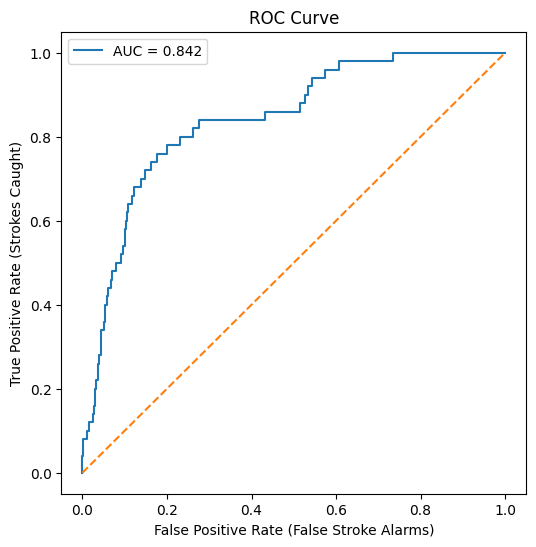

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

false_pos_rate, true_pos_rate, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(false_pos_rate, true_pos_rate, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate (False Stroke Alarms)")
plt.ylabel("True Positive Rate (Strokes Caught)")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators=300, random_state=42, class_weight="balanced")

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)